# Homolog Dataset Statistics
Stats for `homolog_processed.csv`, the self-supervised pretraining data for the masked-residue GNN (see `HomologMaskedDataset` / `pretrain.py`). Homologs are Pfam PF00144 (beta-lactamase) family sequences aligned onto the 1BTL WT structure and filtered to 40-99% identity to WT.

- Basic counts: number of homologs, sequence length, percent identity to WT
- Cluster / train-val-test split statistics (the split actually used by `pretrain.py`)
- Per-position alignment coverage against the WT structure
- Per-position conservation (Shannon entropy) and amino acid frequency landscape
- Naive PSSM-only baseline: how often does the most common homolog residue already match WT?


In [8]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(r'C:\Users\Arthur Zhou\GitHub\aps360_project\src')
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from data.data_class import RESIDUE_LETTERS
from data.data_utils import load_cif_structure, parse_structure
from data.split import split_by_cluster
from train.train_utils import load_config

### Load data

In [2]:
PROCESSED = r'C:\Users\Arthur Zhou\GitHub\aps360_project\src\data\processed'
CONFIG_PATH = r'C:\Users\Arthur Zhou\GitHub\aps360_project\configs\gnn_pretrain.json'

cfg = load_config(CONFIG_PATH)
homolog_df = pd.read_csv(f'{PROCESSED}/homologs/homolog_processed.csv')
pssm_df = pd.read_csv(f'{PROCESSED}/homologs/pssm.csv')
cluster_cache = pd.read_csv(f'{PROCESSED}/homologs/homolog_clusters_cache.csv')

wt_sequence, _ = parse_structure(load_cif_structure(f'{PROCESSED}/1BTL.cif', '1BTL'))
print(f"WT structure length: {len(wt_sequence)}")
homolog_df.head()

WT structure length: 263


,homolog_ID,percent_identity,sequence
0,A0A918YVP8_9ACTN/92-411,0.478469,LDAAVQQTMTQTGVPGVSVGIWLPGQGRYVKSFGVADKKTGAPMTV...
1,A0A099W776_9LIST/2-318,0.439462,LDTLLKKMVTDGVVPGISYAVISPNRTKQHVIGMKQLTPEKLILEP...
2,A0A8J3T2X7_9ACTN/13-333,0.460784,RLAELIEEFEVPGAGLAFLHEGRVHEFAAGVLNTGTGVETTTDSLF...
3,F7W5A7_SORMK/9-422,0.526066,QILHRHTVHPDSPSTKDKLLGASFVVVDKSGPIYSGAAGHTSLPIT...
4,C7DAG1_9RHOB/91-377,0.417840,TSIVVLHYGTLVHQSYHLDTAEGDLRISWSVAKSFLSTLIGILLDE...


### Basic counts

In [3]:
n_homologs = len(homolog_df)
seq_lens = homolog_df['sequence'].str.len()

print(f"Number of homologs: {n_homologs}")
print(f"Homolog sequence length: min={seq_lens.min()}, mean={seq_lens.mean():.1f}, max={seq_lens.max()}")
print(f"Percent identity to WT: min={homolog_df['percent_identity'].min():.3f}, "
      f"mean={homolog_df['percent_identity'].mean():.3f}, max={homolog_df['percent_identity'].max():.3f}")

Number of homologs: 58336
Homolog sequence length: min=34, mean=323.1, max=530
Percent identity to WT: min=0.400, mean=0.460, max=0.985


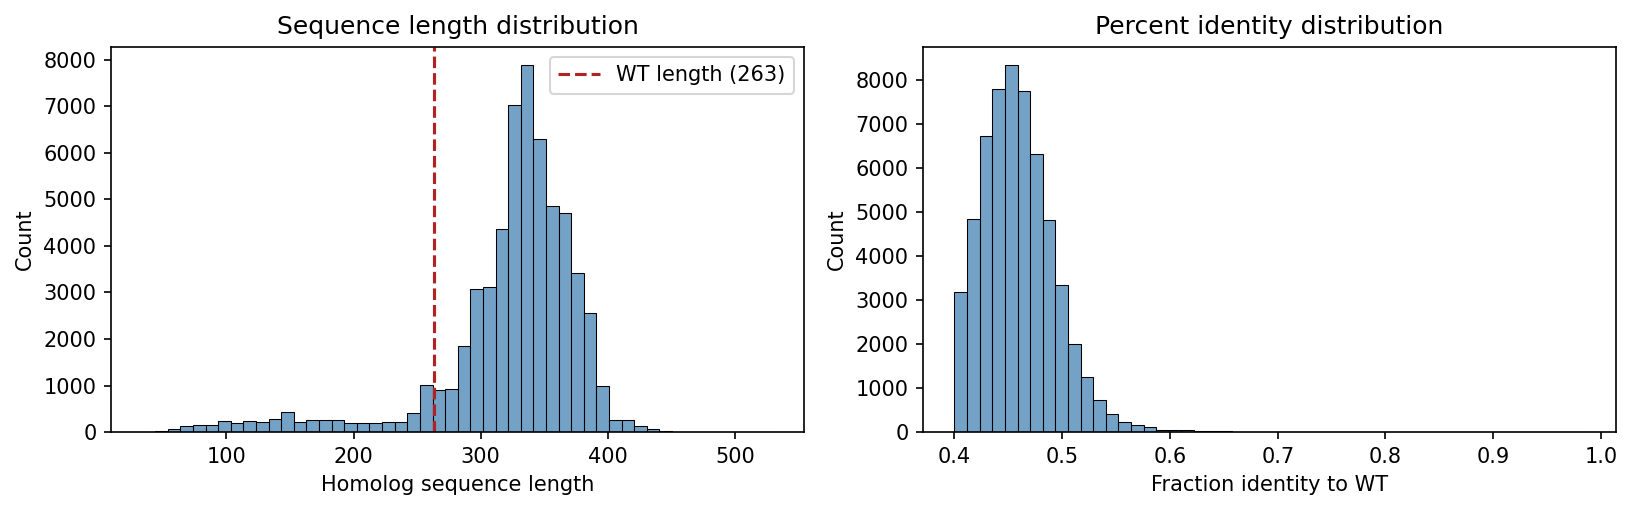

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), dpi=150)

sns.histplot(seq_lens, bins=50, color="steelblue", ax=axes[0])
axes[0].axvline(len(wt_sequence), color="firebrick", linestyle="--", label=f"WT length ({len(wt_sequence)})")
axes[0].set_xlabel("Homolog sequence length")
axes[0].set_title("Sequence length distribution")
axes[0].legend()

sns.histplot(homolog_df['percent_identity'], bins=50, color="steelblue", ax=axes[1])
axes[1].set_xlabel("Fraction identity to WT")
axes[1].set_title("Percent identity distribution")

plt.tight_layout()
plt.show()

### Cluster / train-val-test split statistics
Homologs are split by k-mer cluster (`split_by_cluster`), not by row, so near-duplicate sequences never leak across train/val/test - this is the split `pretrain.py` and `infer_pretrain.py` both actually use (same `cache_path`, so results here match what training sees).

In [5]:
cluster_sizes = cluster_cache.groupby('cluster').size()

print(f"Number of clusters: {cluster_cache['cluster'].nunique()}")
print(f"Cluster size: min={cluster_sizes.min()}, mean={cluster_sizes.mean():.2f}, max={cluster_sizes.max()}")
print(f"Singleton clusters (size 1): {(cluster_sizes == 1).sum()} ({(cluster_sizes == 1).mean():.1%} of clusters)")

Number of clusters: 52286
Cluster size: min=1, mean=1.12, max=309
Singleton clusters (size 1): 49534 (94.7% of clusters)


In [6]:
train_df, val_df, test_df = split_by_cluster(
    homolog_df, train_frac=cfg.data.train_size, val_frac=cfg.data.val_size, seed=cfg.seed,
    k=cfg.data.cluster_kmer_k, threshold=cfg.data.cluster_similarity_threshold,
    cache_path=f'{PROCESSED}/homologs/homolog_clusters_cache.csv',
)

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: {len(split)} homologs ({len(split) / n_homologs:.1%})")

train: 46668 homologs (80.0%)
val: 5834 homologs (10.0%)
test: 5834 homologs (10.0%)


### Per-position alignment coverage against the WT structure
`pssm.csv`'s `n_observed` column counts how many family members (homologs + WT itself) align to each WT position. This is the effective sample size available for masked-residue training at each site - positions near the N/C-termini, where alignments often fray, get systematically less signal.

Per-position coverage: min=33085, mean=45534, max=52663 (out of 58337 possible, incl. WT)


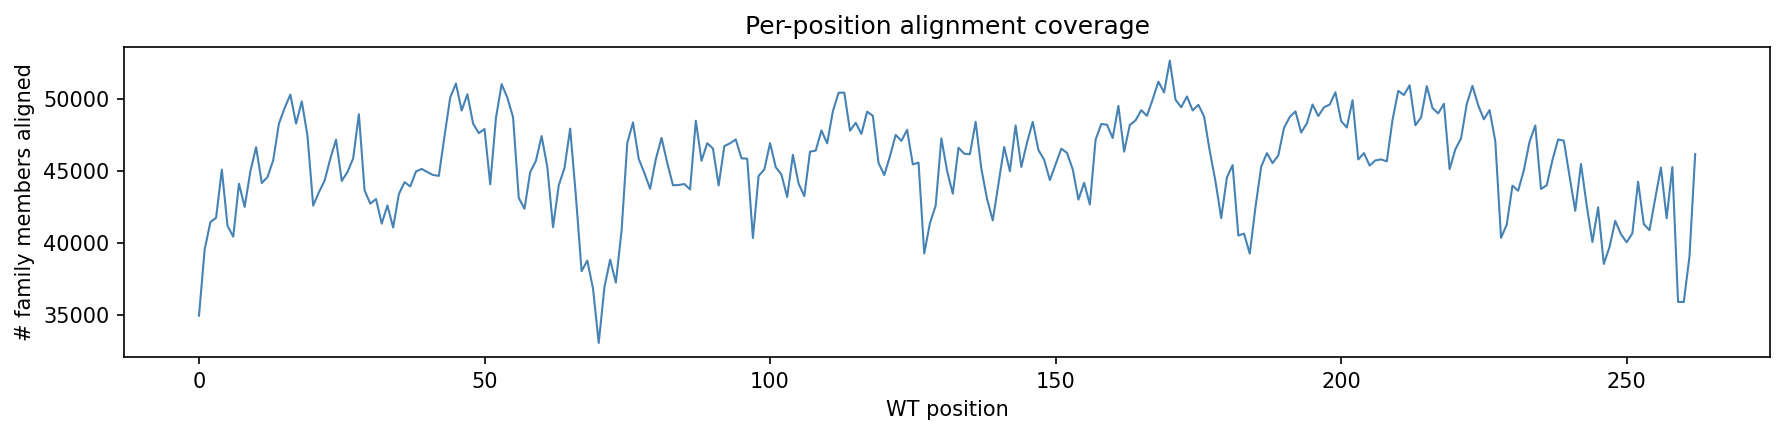

In [7]:
coverage = pssm_df['n_observed']

print(f"Per-position coverage: min={coverage.min()}, mean={coverage.mean():.0f}, "
      f"max={coverage.max()} (out of {n_homologs + 1} possible, incl. WT)")

plt.figure(figsize=(12, 3), dpi=150)
plt.plot(pssm_df['wt_position'], coverage, color="steelblue", lw=1)
plt.xlabel("WT position")
plt.ylabel("# family members aligned")
plt.title("Per-position alignment coverage")
plt.tight_layout()
plt.show()

### Per-position conservation and amino acid frequency landscape
New stats, not present in `data_stats.ipynb` (which covers DMS *designed* mutations): Shannon entropy per position measures natural evolutionary constraint directly from the homolog family, and the frequency heatmap is the natural-variation analogue of the DMS notebook's "Mutation Landscape" heatmap.

In [7]:
freqs

array([[0.07497571, 0.03480199, 0.02191554, ..., 0.01488656, 0.01782959,
        0.10794903],
       [0.07255967, 0.08225786, 0.02881677, ..., 0.00434398, 0.00997601,
        0.04586438],
       [0.09798959, 0.05450294, 0.02434674, ..., 0.00609874, 0.01125735,
        0.02429852],
       ...,
       [0.09601313, 0.04701889, 0.02554044, ..., 0.00456278, 0.0216732 ,
        0.09492808],
       [0.14016779, 0.04985165, 0.02915899, ..., 0.0037344 , 0.04596378,
        0.08793738],
       [0.12781337, 0.06295447, 0.02975675, ..., 0.07834141, 0.04616084,
        0.08083016]], shape=(263, 20))

Per-position entropy: min=1.71, mean=3.13, max=4.16 bits (uniform max: 4.32)


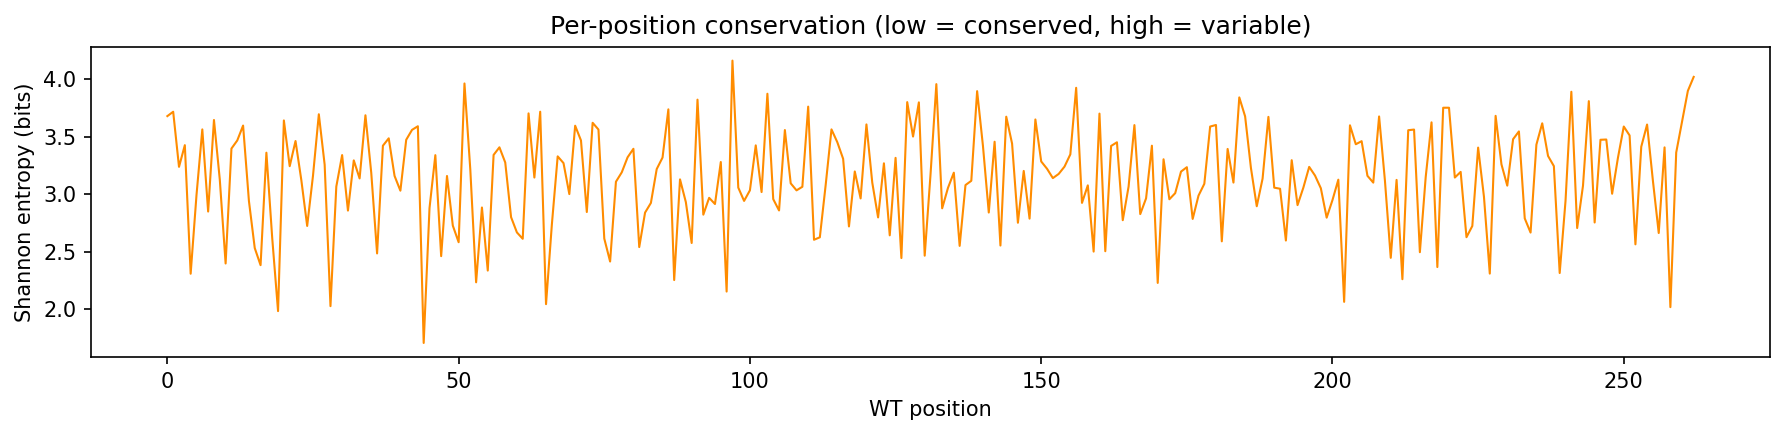

In [6]:
freqs = pssm_df[RESIDUE_LETTERS].to_numpy()
entropy = -(freqs * np.log2(freqs)).sum(axis=1)  # bits; max possible = log2(20) for a fully uniform position

print(f"Per-position entropy: min={entropy.min():.2f}, mean={entropy.mean():.2f}, "
      f"max={entropy.max():.2f} bits (uniform max: {np.log2(20):.2f})")

plt.figure(figsize=(12, 3), dpi=150)
plt.plot(pssm_df['wt_position'], entropy, color="darkorange", lw=1)
plt.xlabel("WT position")
plt.ylabel("Shannon entropy (bits)")
plt.title("Per-position conservation (low = conserved, high = variable)")
plt.tight_layout()
plt.show()

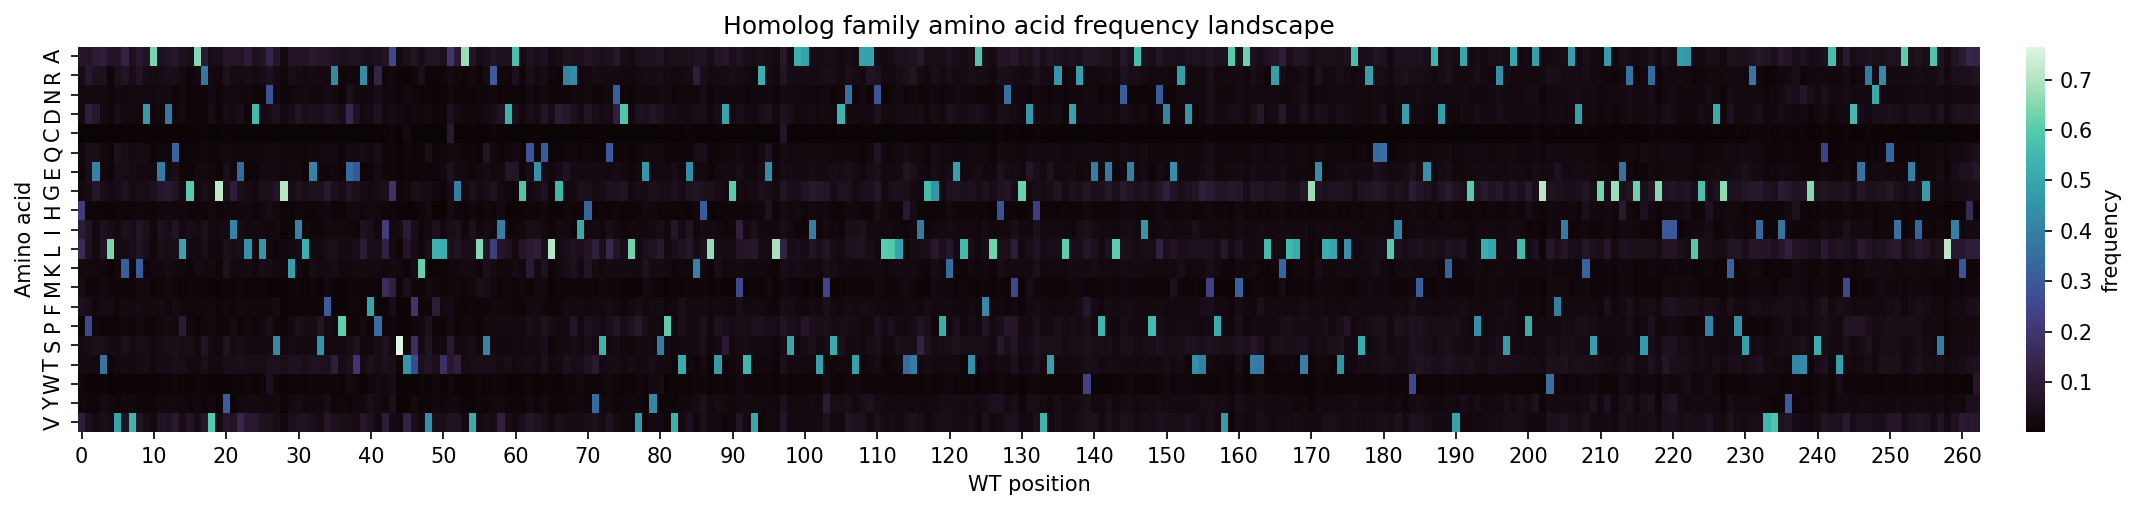

In [9]:
plt.figure(figsize=(16, 3.5), dpi=150)
ax = sns.heatmap(
    freqs.T,
    cmap="mako",
    xticklabels=10,
    yticklabels=RESIDUE_LETTERS,
    linewidths=0,
    cbar_kws={"label": "frequency", "pad": 0.02},
)
ax.set_xlabel("WT position")
ax.set_ylabel("Amino acid")
ax.set_title("Homolog family amino acid frequency landscape")
plt.tight_layout()
plt.show()

### Does family conservation alone recover WT?
A naive, structure-free baseline: at each position, is WT's residue the *most frequent* one across the homolog family? This is directly comparable to the wildtype-recovery `accuracy` metric now computed in `infer_pretrain.py` / `infer_zero_shot.py` - it's what conservation alone gets you, with no GNN and no 3D structure.

In [10]:
wt_encoded = np.array([RESIDUE_LETTERS.index(aa) for aa in wt_sequence])
pssm_argmax = freqs.argmax(axis=1)
pssm_matches_wt = pssm_argmax == wt_encoded

print(f"Positions where the most frequent homolog residue matches WT: "
      f"{pssm_matches_wt.sum()}/{len(wt_sequence)} ({pssm_matches_wt.mean():.1%})")

Positions where the most frequent homolog residue matches WT: 257/263 (97.7%)


### Example homolog rows

In [11]:
homolog_df.sample(5, random_state=1012).assign(sequence=lambda d: d['sequence'].str.slice(0, 60) + "...")

,homolog_ID,percent_identity,sequence
8672,A0A940FY13_9MICO/63-404,0.430493,VPALVADALEQTGVPGLAVAIVHGDETVYAAGFGTKAAGTDEPIDA...
41721,A0A9W9KW34_9EURO/12-374,0.421053,FNELVKEQLEKWKVPGLSIAIINGSNTYSNSRSGIGSSQTQQAYGQ...
50947,A0A5N8XUA7_9ACTN/17-340,0.449074,LHRIAVAQAEGRAPSMVAAVVRGGRTVWTGARTSVEGHAPDENTQY...
56224,A0A1I0ZA98_9PSEU/14-267,0.470270,NASTAVVAADGRVLGSHGDTSRVYPLASVTKLLTAYTALIAIEEGV...
52883,A0A940RI37_9CAUL/136-453,0.402655,AAIRTARDKIRLEGAAGRFSGASLVAAGRQVLLSAAQGLADEAAQT...
